## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))


from src.phrase_analysis import process_directory, plot_phrases_individual_all, plot_phrase_frequency_over_time_all, plot_length_distribution, analyze_files_phrase_occurrences, get_recent_contexts_all, get_per_appearance_frequency, calculate_poisson_predictions, calculate_negative_binomial_predictions, format_prediction_table, get_phrases, process_json
from src.regex_pattern_generator import generate_regex_patterns
from datetime import datetime
import pandas as pd

In [2]:
CONTEXT_WINDOW = 200  # words to display for context

## Define Search Phrases

We'll analyze the following key phrases in press briefings:
Deport
America First
Ukraine
Israel
DOGE / Department of Government Efficiency / Doge
Russia
Elon / Musk
Inflation
Fraud
Intelligence
Crypto
Lawsuit
Egg
GM
Interest Rate
CBS
Ford
Chrysler
Debt Ceiling
Sylvester / Turner

In [3]:
PHRASES = get_phrases("KXBERNIEMENTION-26MAR28")
if "Zohran / Mamdani" in PHRASES:
    PHRASES.remove("Zohran / Mamdani")
    PHRASES.append("Zohran / Zoran / Zoron / Mamdani / Mandani")

if "One Percent" in PHRASES:
    PHRASES.remove("One Percent")
PHRASES.append("One Percent / 1 Percent / 1% / 1%ers / 1%er / One %")

import re
PHRASES = [re.sub(r"\s*\([^)]*\)", "", phrase).strip() for phrase in PHRASES]



SEARCH_PHRASES = generate_regex_patterns(PHRASES)
SEARCH_PHRASES['Oligarch'] = "\\b(?:\\w+-)*(?:oligarch|oligarchs|oligarch's|oligarchs'|oligarches')(?:-\\w+)*(?=\\W|$)[.,!?;:]*"
from pprint import pprint
pprint(SEARCH_PHRASES)

{'Afford / Affordable / Affordability': "\\b(?:\\w+-)*(?:(?:afford|affords|afford's|affords'|affordable|affordables|affordable's|affordables'|affordability|affordabilities|affordability's|affordabilitys'|affordabilities'))(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Bernie': "\\b(?:\\w+-)*(?:bernie|bernies|bernie's|bernies')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Billionaire': "\\b(?:\\w+-)*(?:billionaire|billionaires|billionaire's|billionaires')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Bipartisan': "\\b(?:\\w+-)*(?:bipartisan|bipartisans|bipartisan's|bipartisans')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Climate': "\\b(?:\\w+-)*(?:climate|climates|climate's|climates')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Corrupt / Corruption': "\\b(?:\\w+-)*(?:(?:corrupt|corrupts|corrupt's|corrupts'|corruption|corruptions|corruption's|corruptions'))(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Election': "\\b(?:\\w+-)*(?:election|elections|election's|elections')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Elon / Musk': "\\b(?:\\w+-)*(?:(?:elon|elons|elon's|elons'|mus

In [4]:
# Process press briefing transcripts
df = process_directory('../data-bernie/processed-transcripts', SEARCH_PHRASES)
df = df.sort_values('date')

# Print dataset statistics
print("Dataset Statistics:")
print(f"Total briefings: {len(df)}")

print("\nWord Count Statistics:")
print(f"Average length: {df['text_length'].mean():.0f} words")

print("\nDate Range:")
# Handle NaT values when printing date ranges
date_min = df['date'].min()
date_max = df['date'].max()
if pd.notna(date_min) and pd.notna(date_max):
    print(f"{date_min.strftime('%Y-%m-%d')} to {date_max.strftime('%Y-%m-%d')}")
else:
    print("No valid dates")

Found 37 .txt files to process with 24 patterns...

Completed processing 37 files.
Categories found in directory:
- processed-transcripts
Dataset Statistics:
Total briefings: 37

Word Count Statistics:
Average length: 5029 words

Date Range:
2019-01-01 to 2026-01-20


In [5]:
# Print the titles (filenames) in chronological order
print("\nTitles in Chronological Order:")
for file in df.sort_values('date')['file']:
    print(file)



Titles in Chronological Order:
2019_2_5_cnn_town_hall.txt
20241001.LIVE from UT-Austin with AOC, Greg Casar, and Beto O'Rourke (LIVE at 630pm ET).txt
Rally with Bernie & AOC in Madison, WI (LIVE at 830PM ET).20241029.txt
FIGHTING OLIGARCHY (LIVE at 1230PM ET).20250222.txt
FIGHTING OLIGARCHY (LIVE at 730PM ET).20250222.txt
Fighting Oligarchy Where We Go From Here with Bernie Sanders in Kenosha (LIVE at 730PM ET).20250308.txt
LIVE from Warren, MI Fighting Oligarchy in America.20250308.txt
Fighting Oligarchy with Bernie Sanders in Altoona (Broadcast at 630PM ET).20250309.txt
LIVE from Las Vegas with @AOC and @StevenHorsford.20250320.txt
Fighting Oligarchy with Bernie and AOC (LIVE at 3PM ET).20250321.txt
LIVE from Tempe with @AOC (LIVE at 9PM ET).20250321.txt
Fighting Oligarchy with Bernie, AOC, and Greg Casar.20250322.txt
Fighting Oligarchy with Bernie and @AOC  (LIVE at 7PM ET).20250322.txt
2025-4-9_cnn_town_hall.txt
FIGHT THE OLIGARCHY WITH BERNIE AND AOC LOS ANGELES.20250412.txt
FIGH


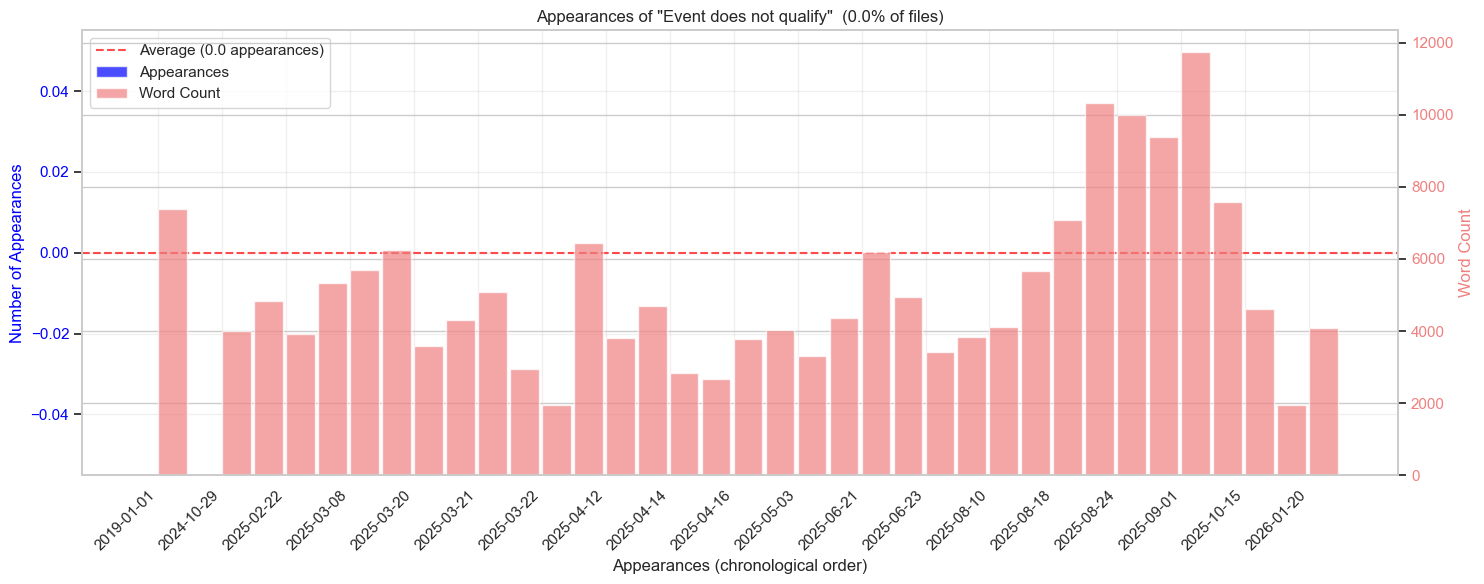


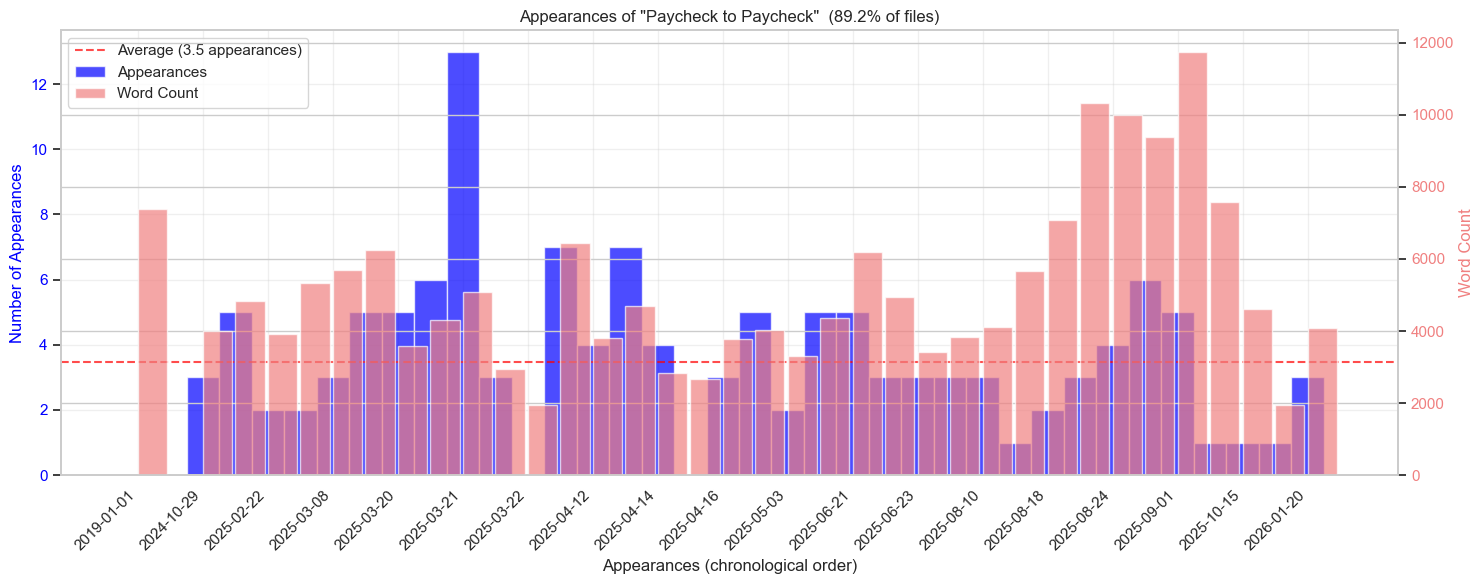


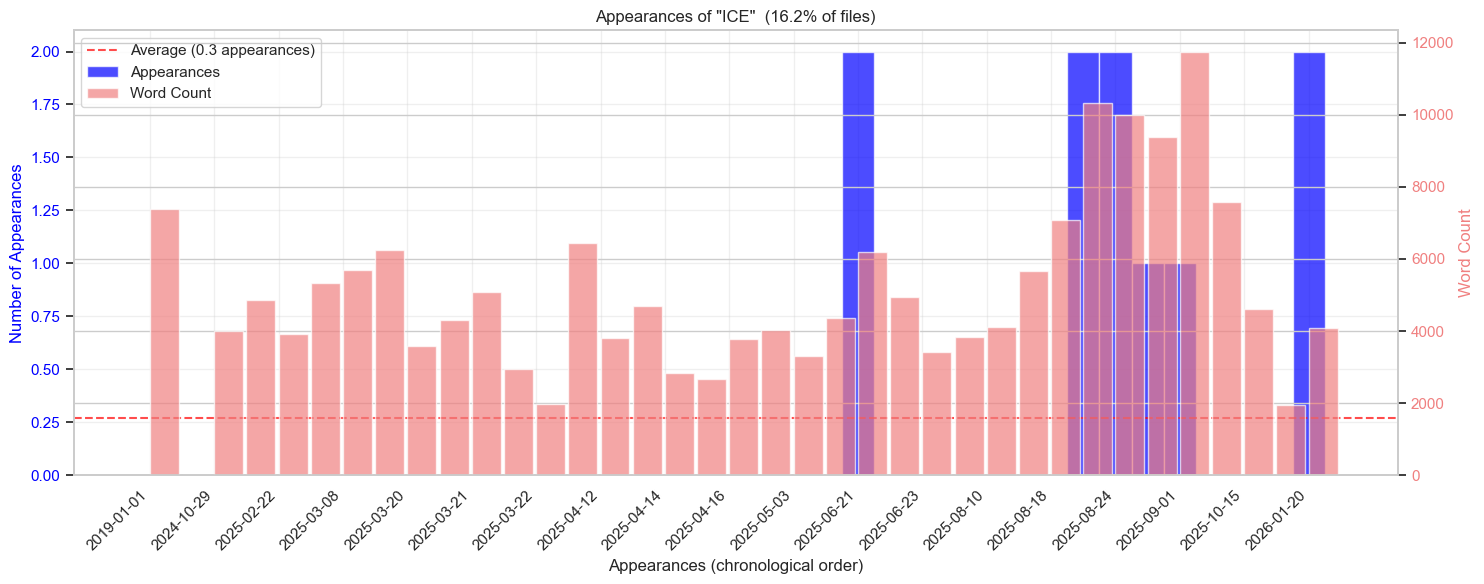


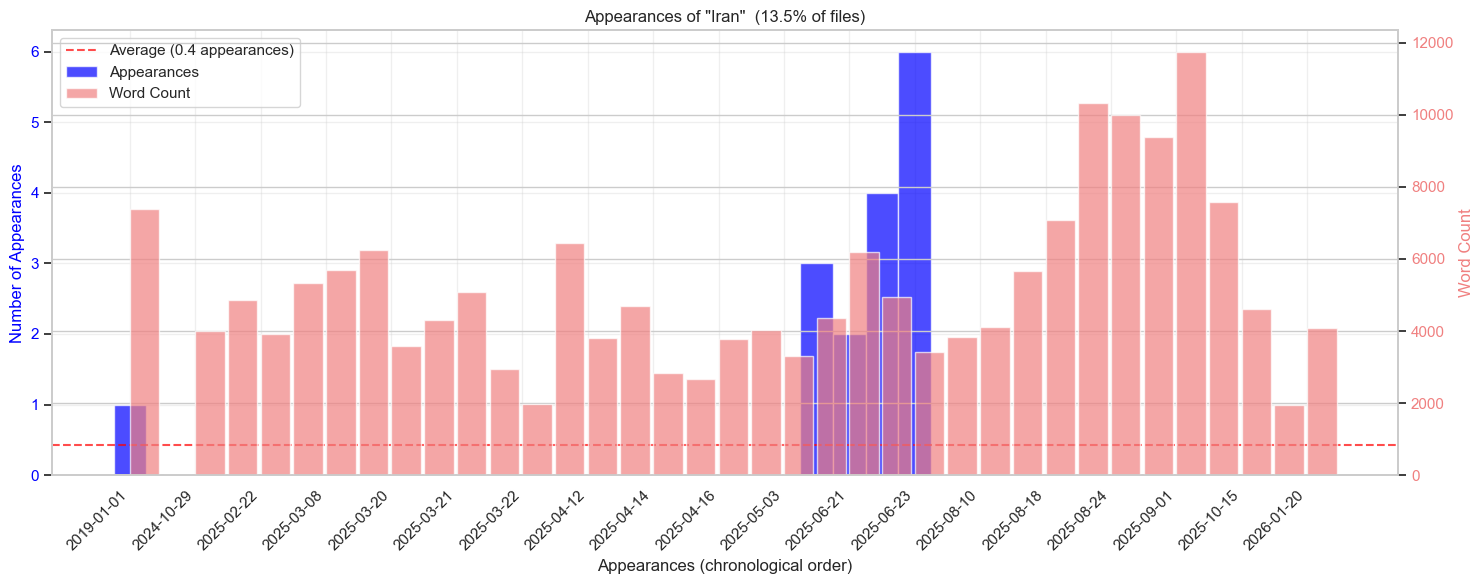


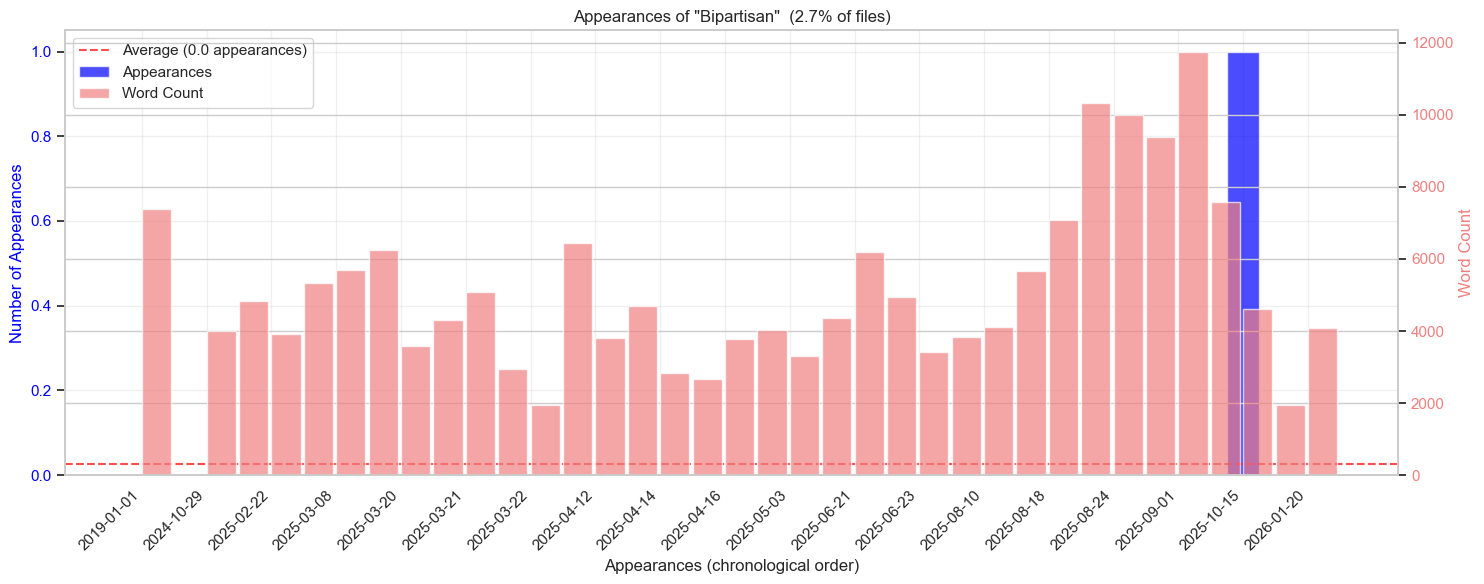


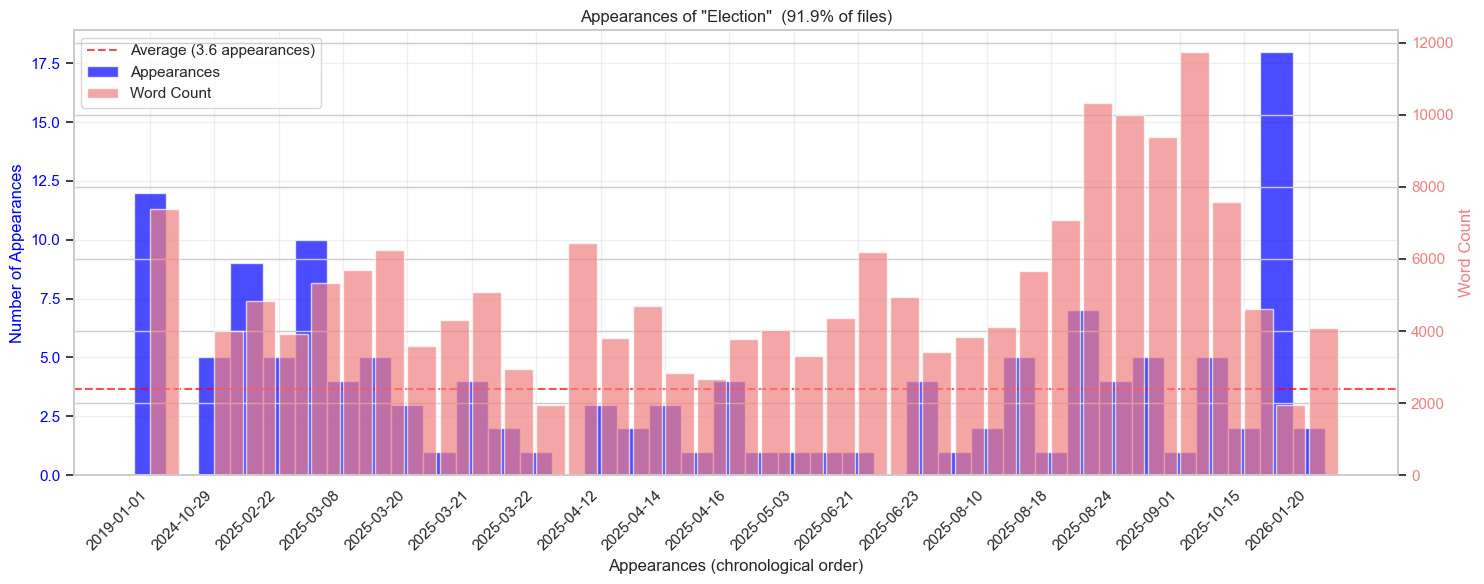


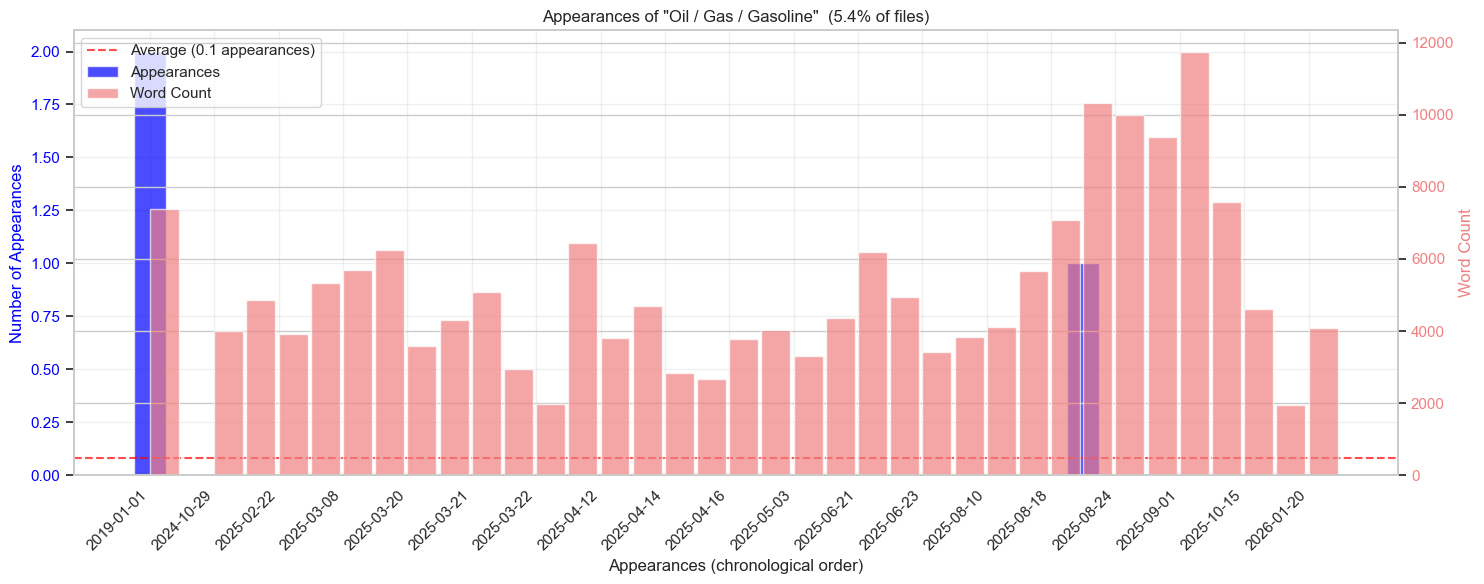


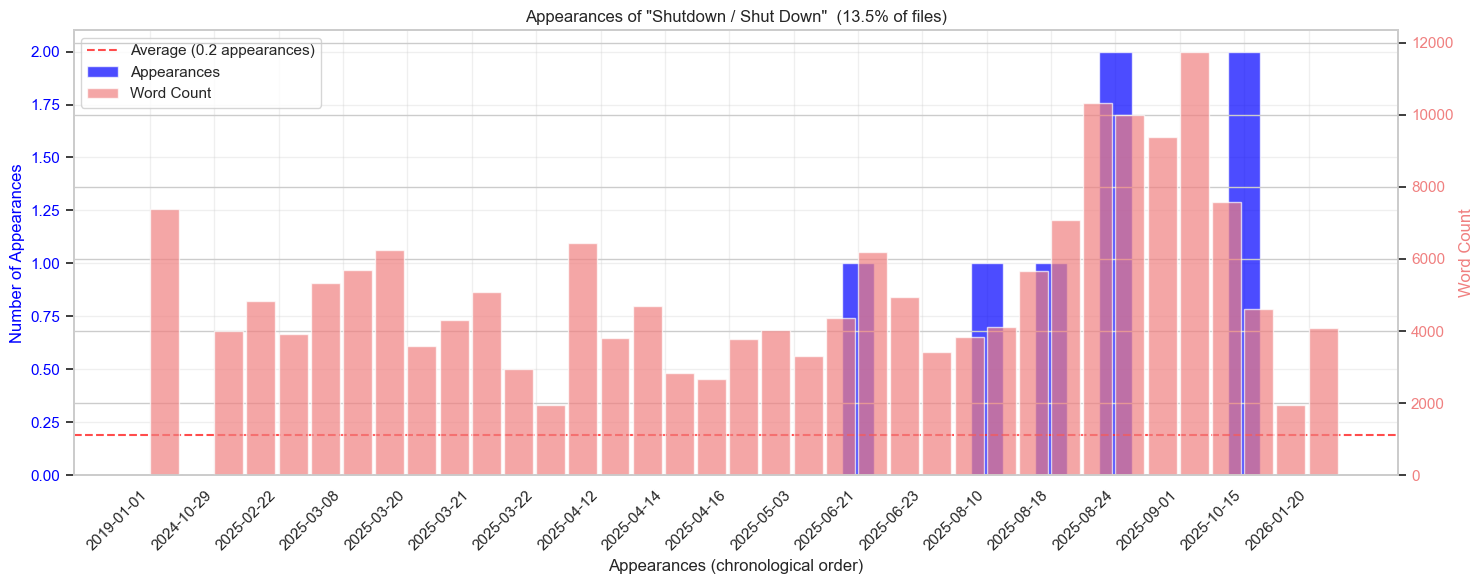


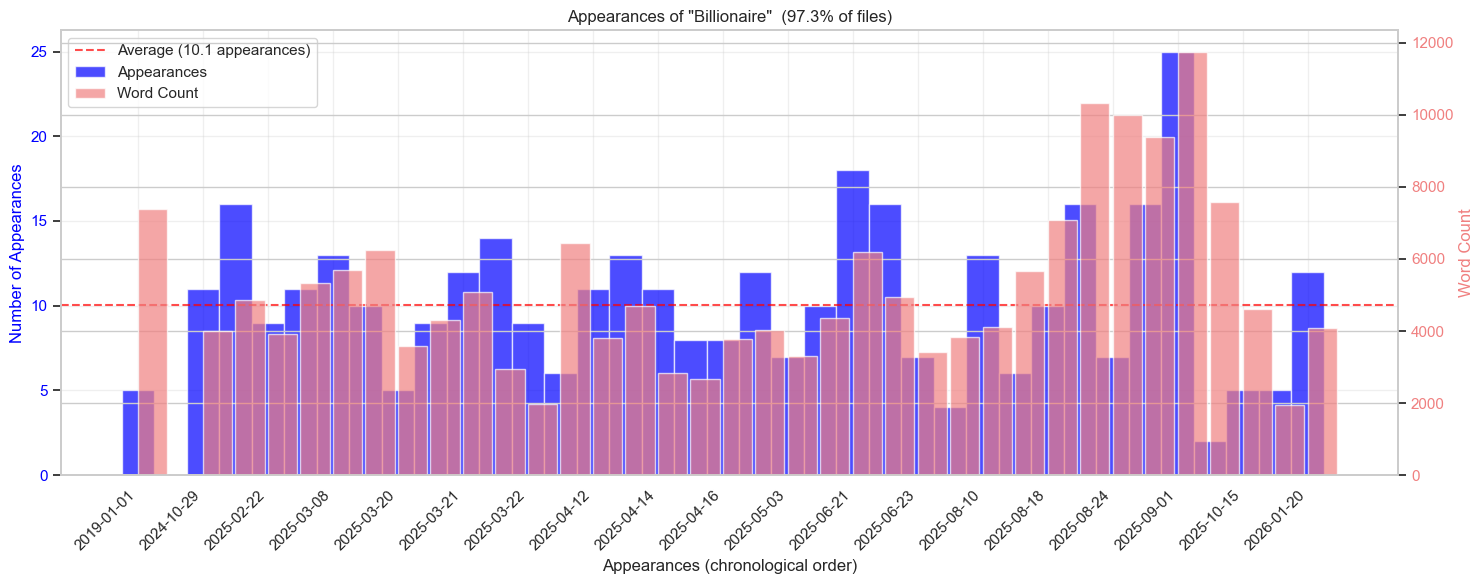


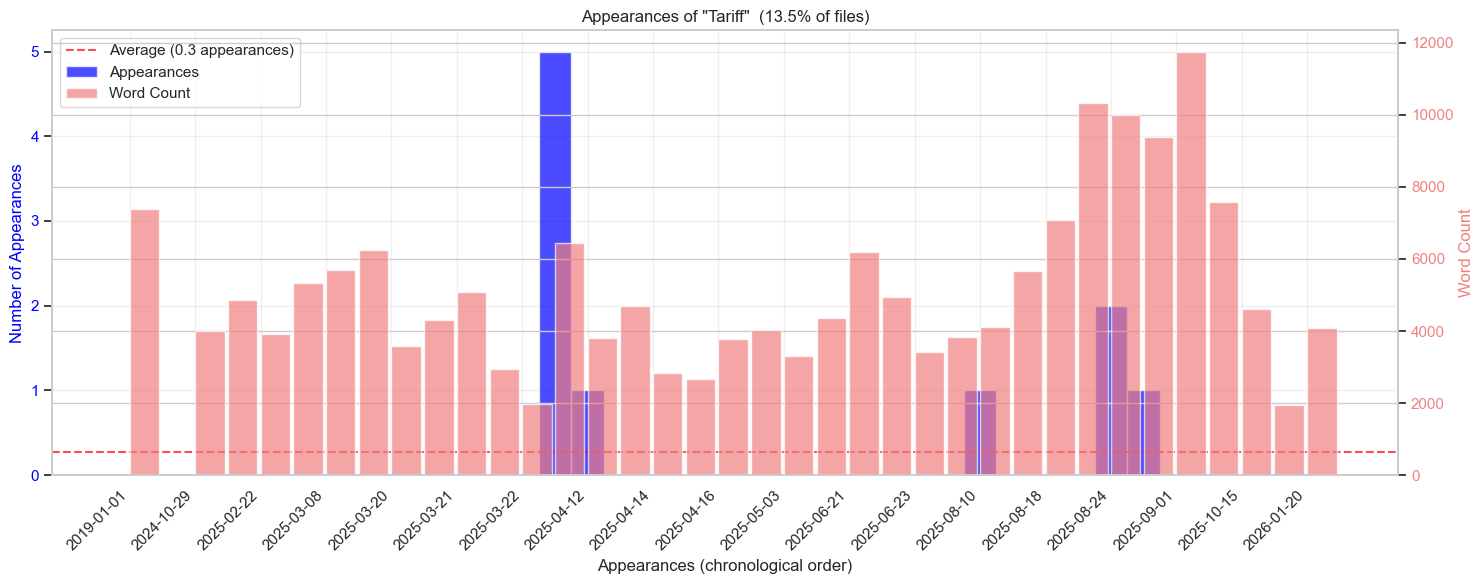


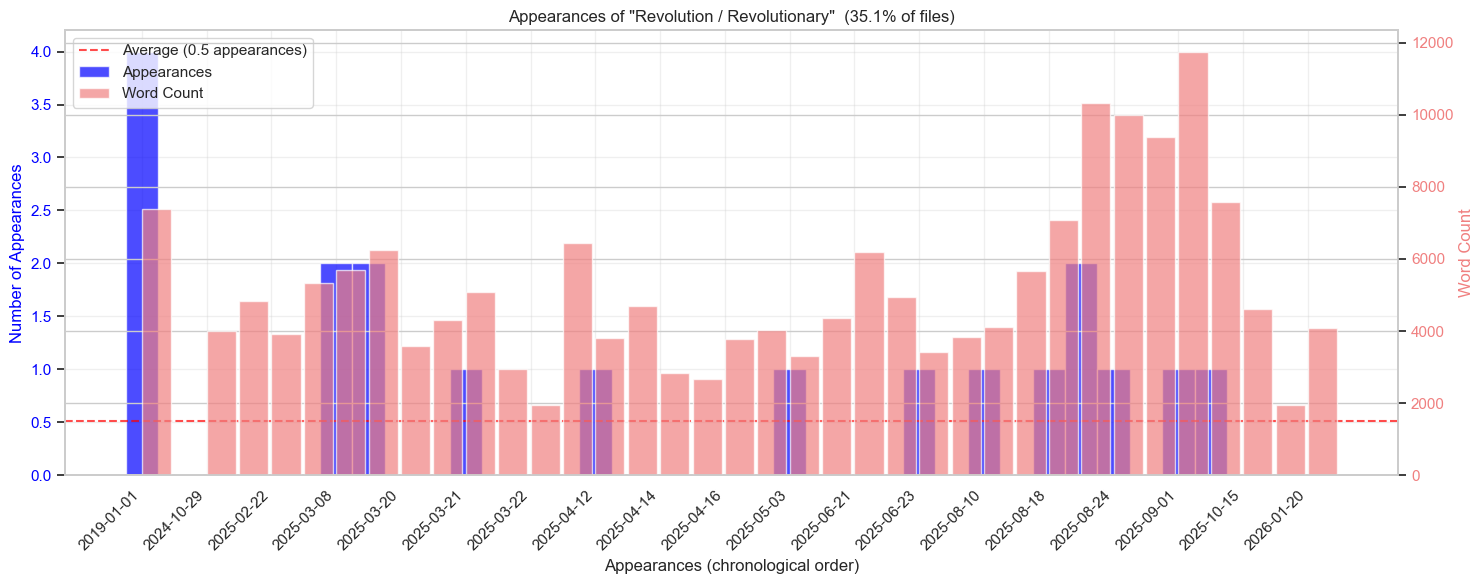


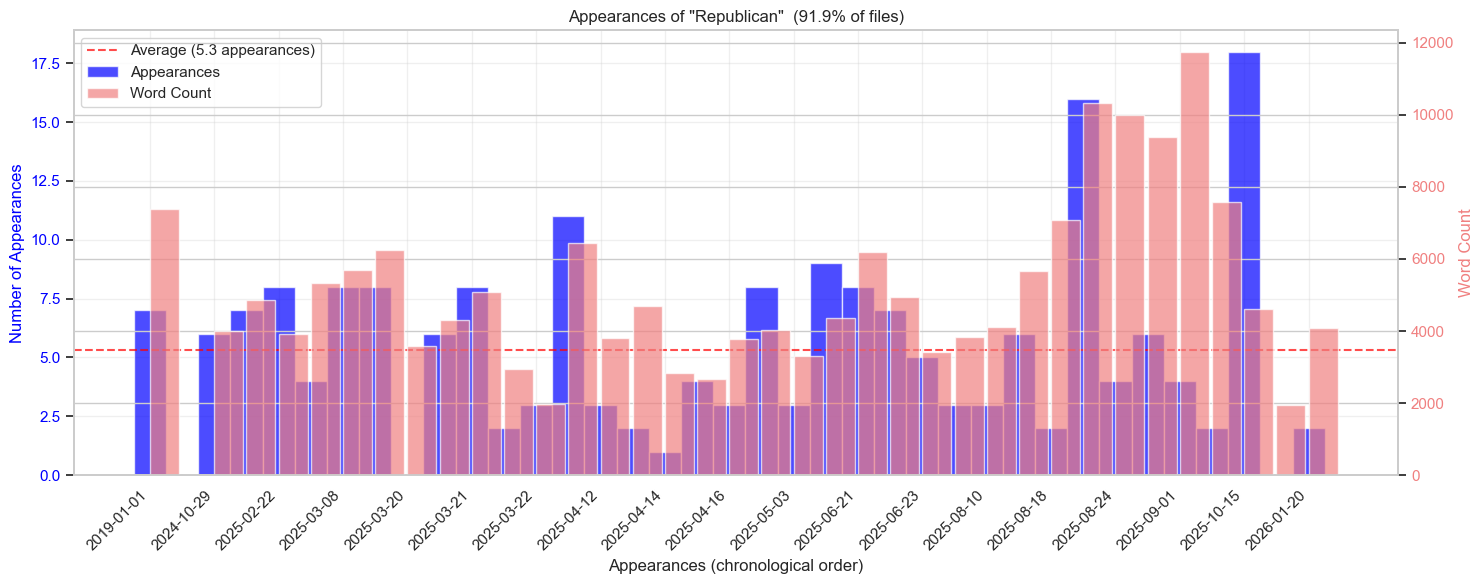


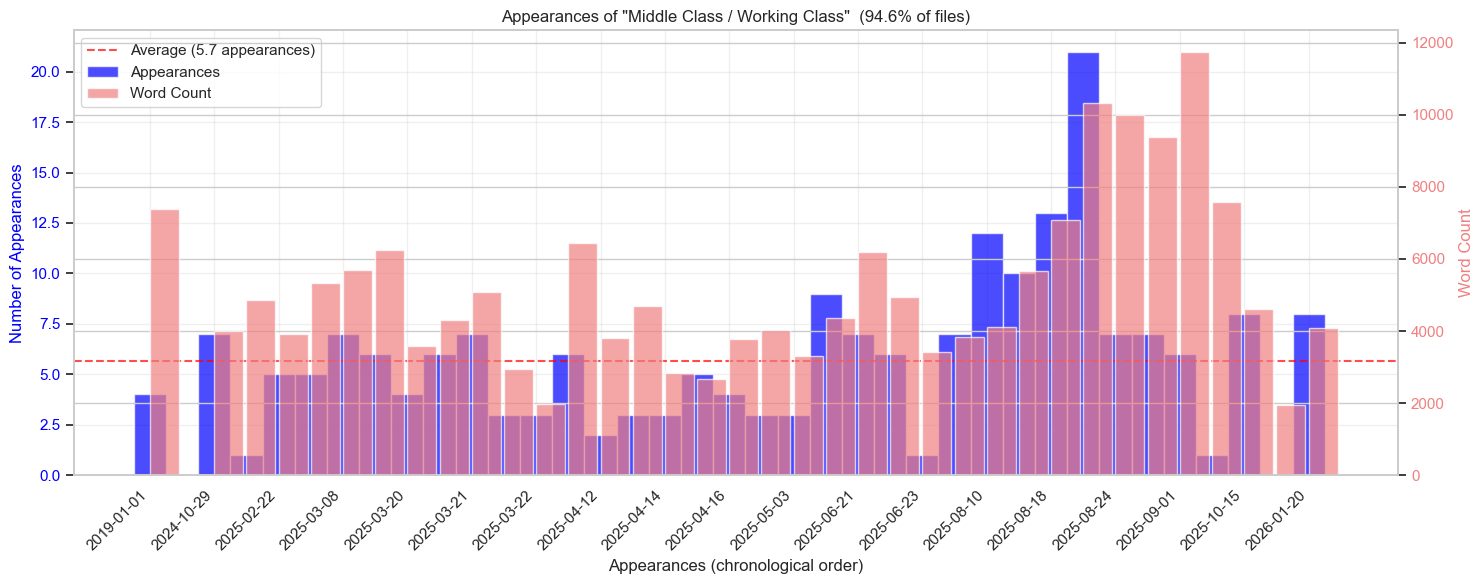


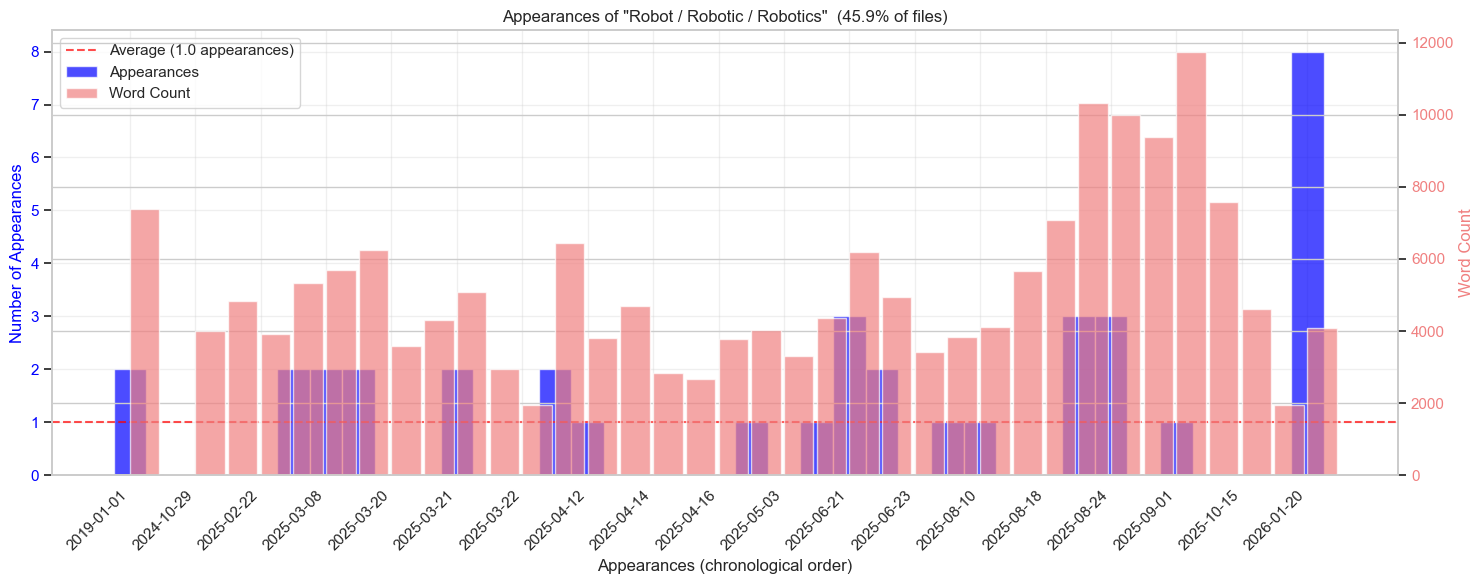


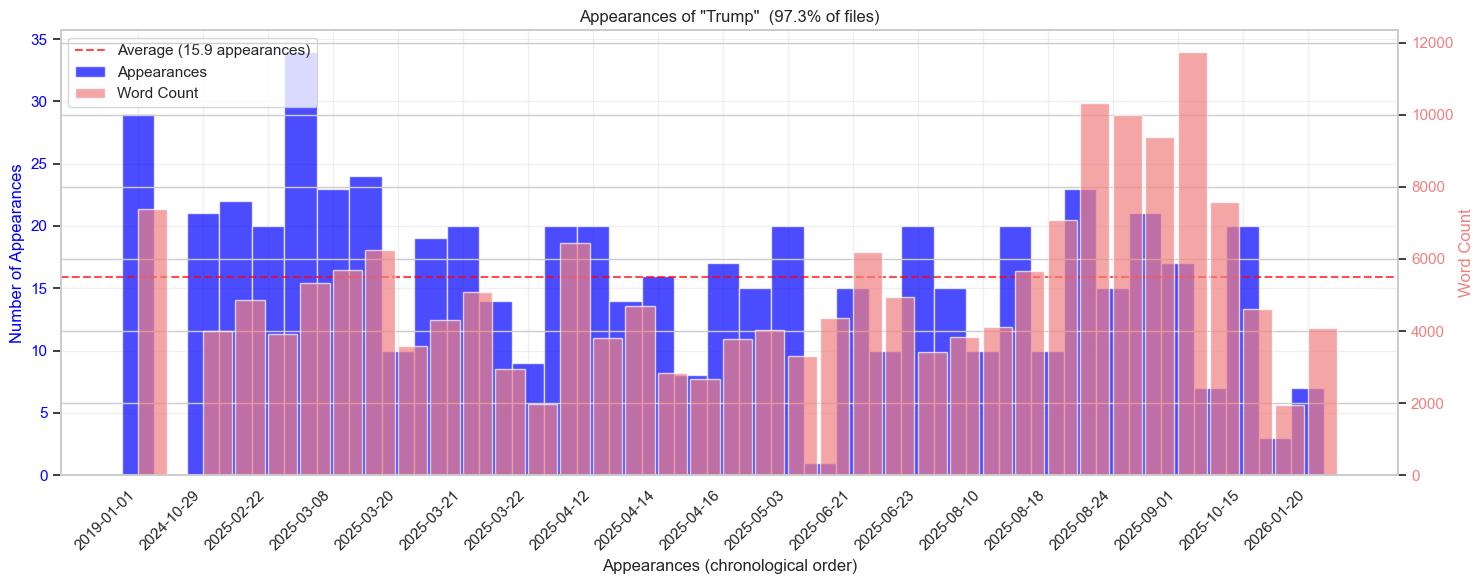


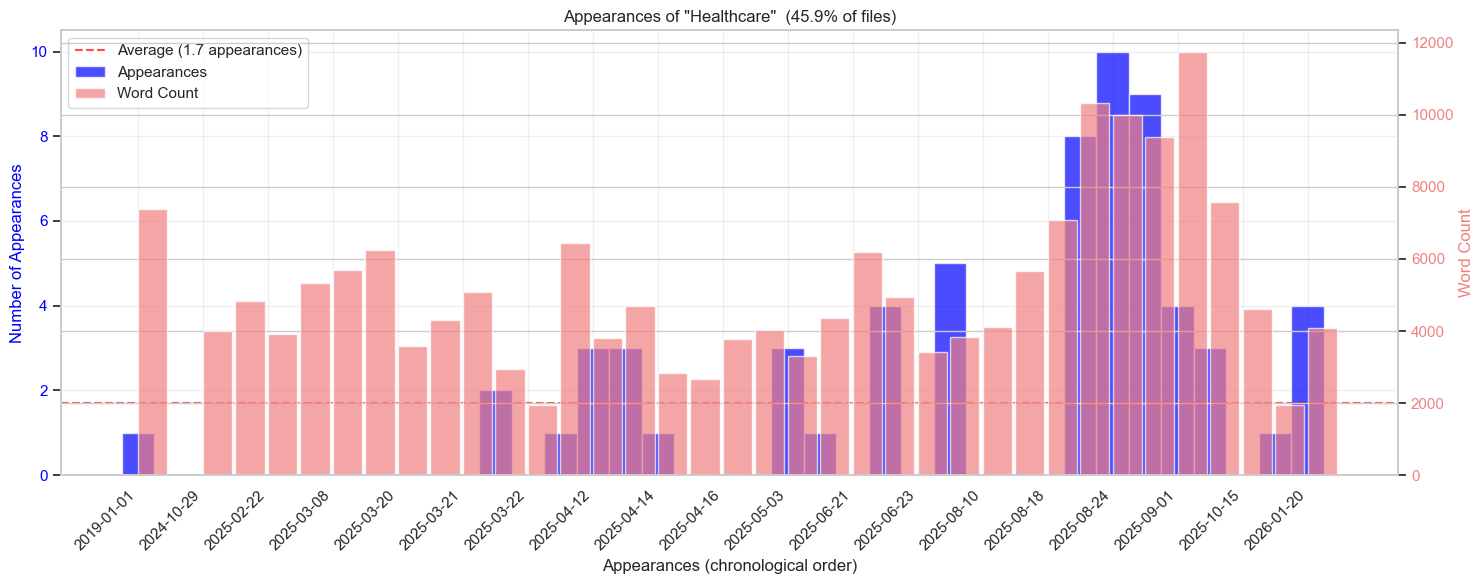


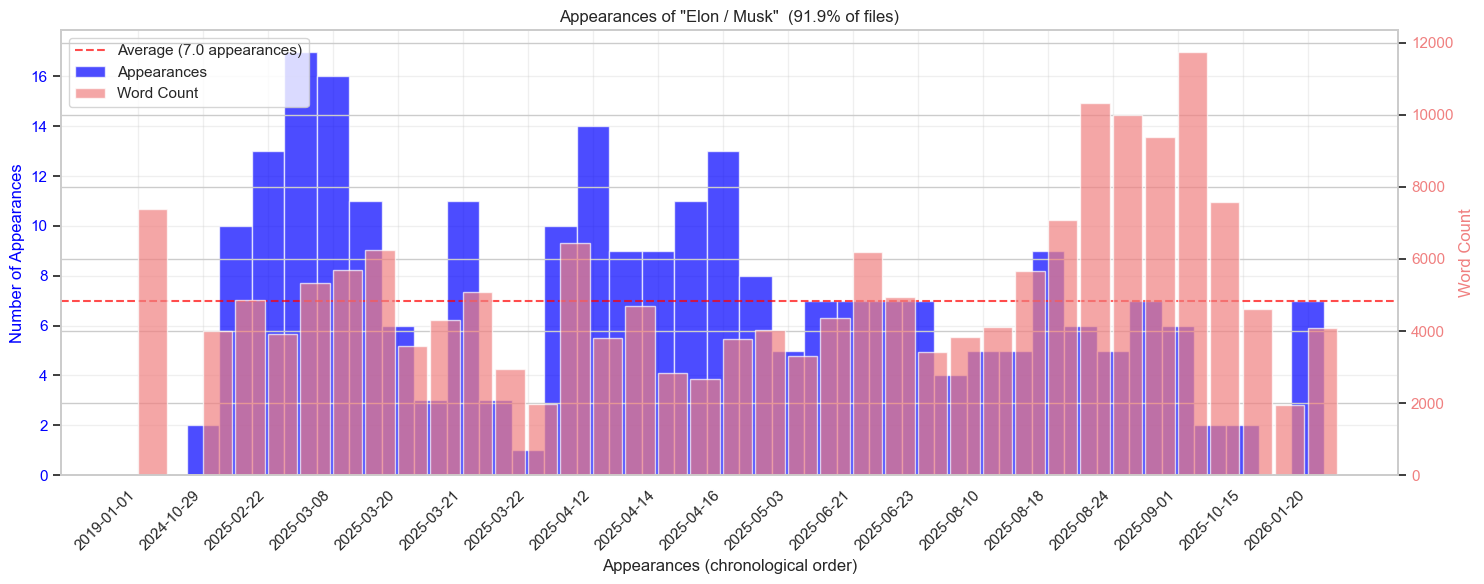


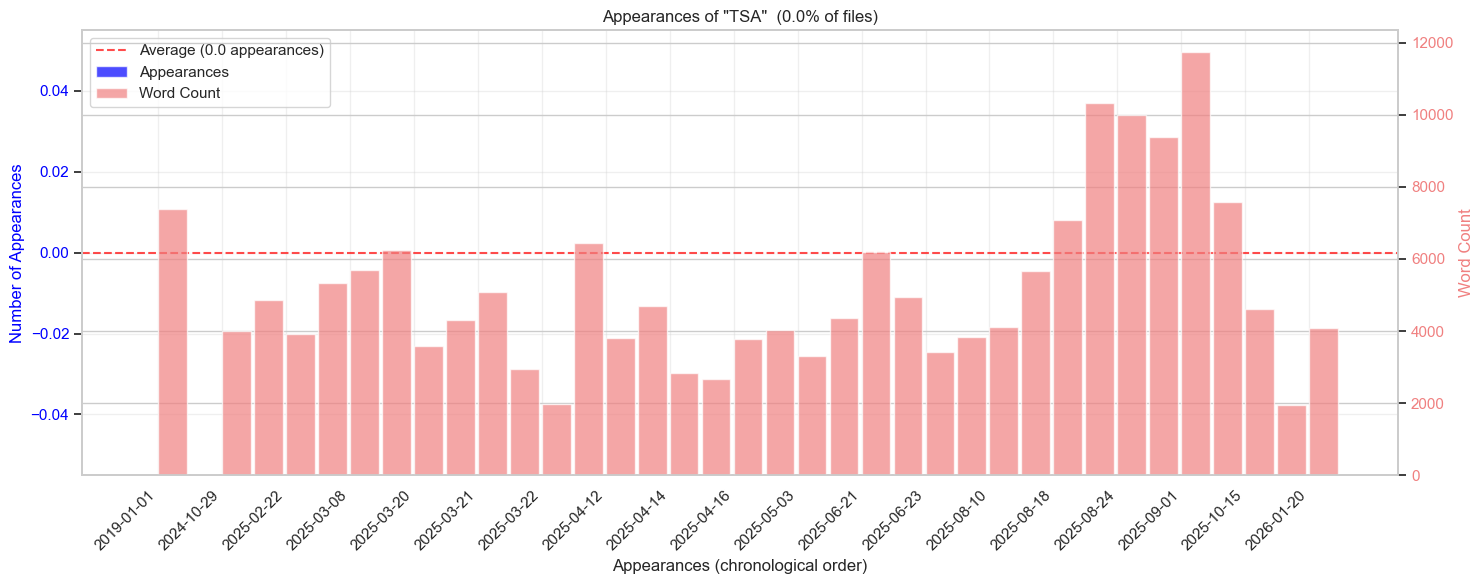


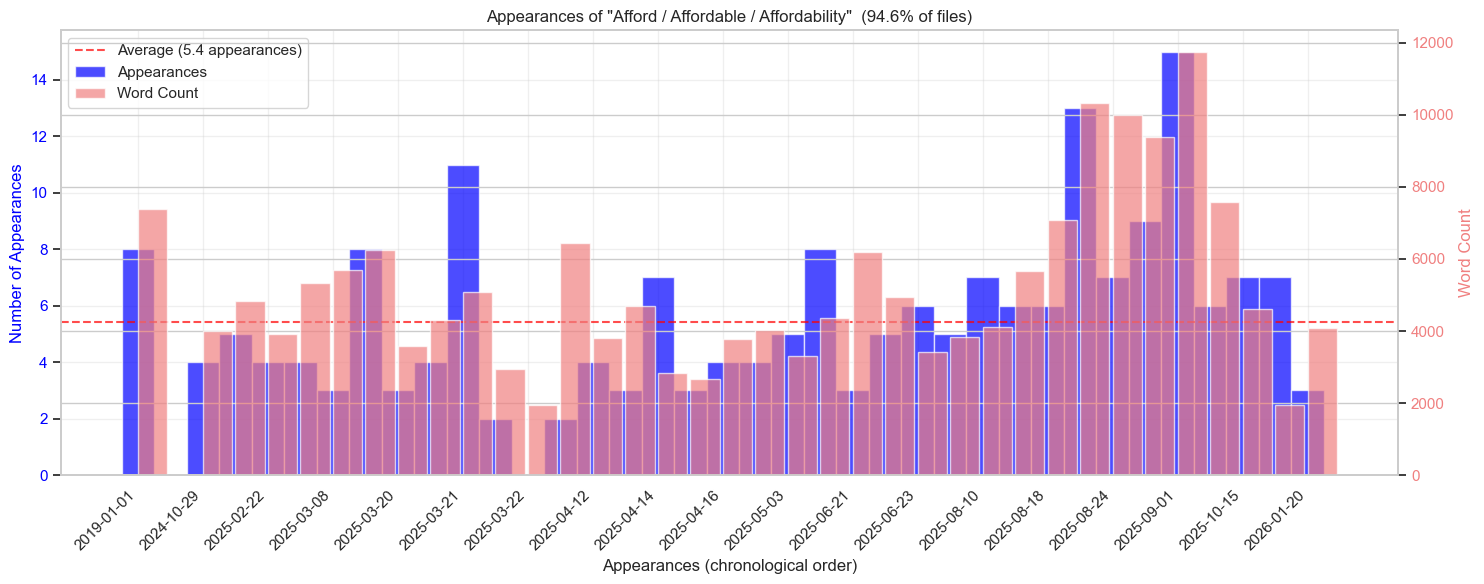


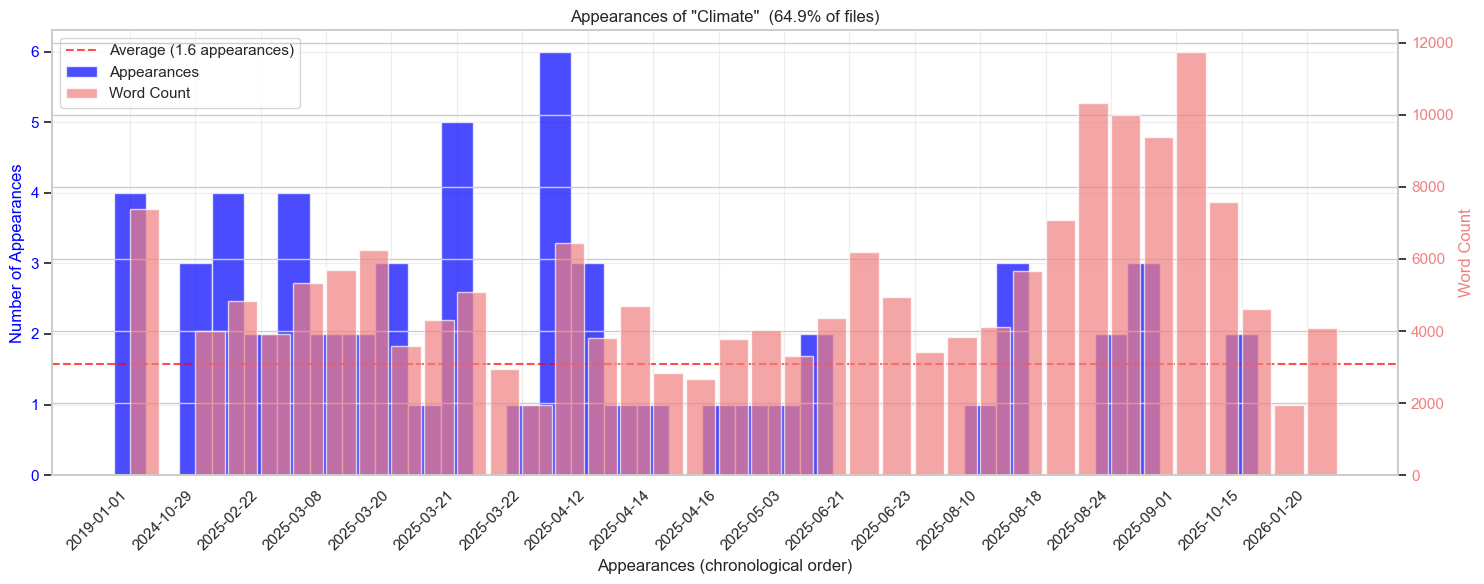


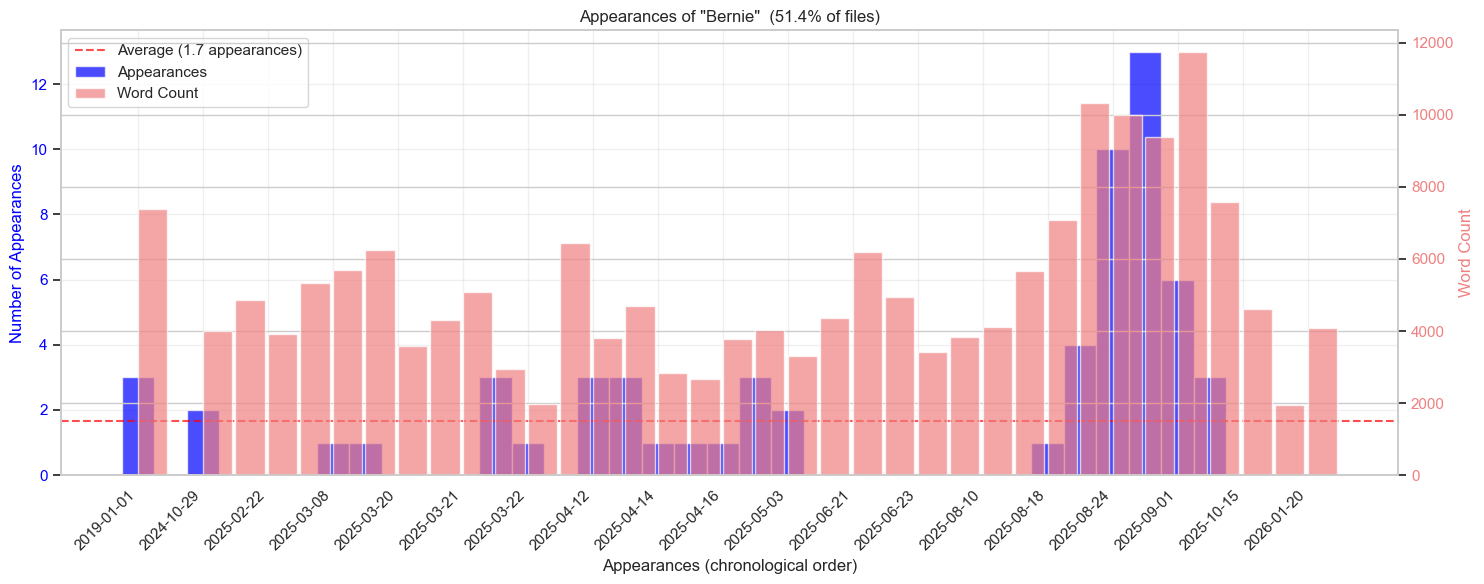


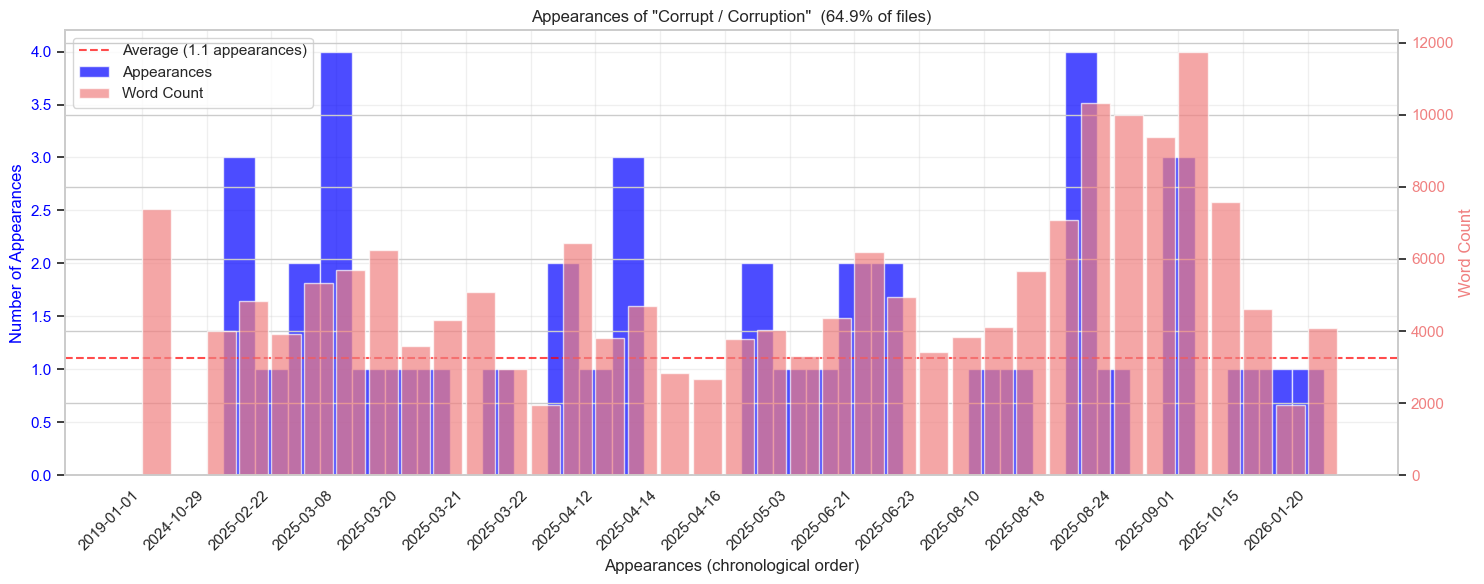


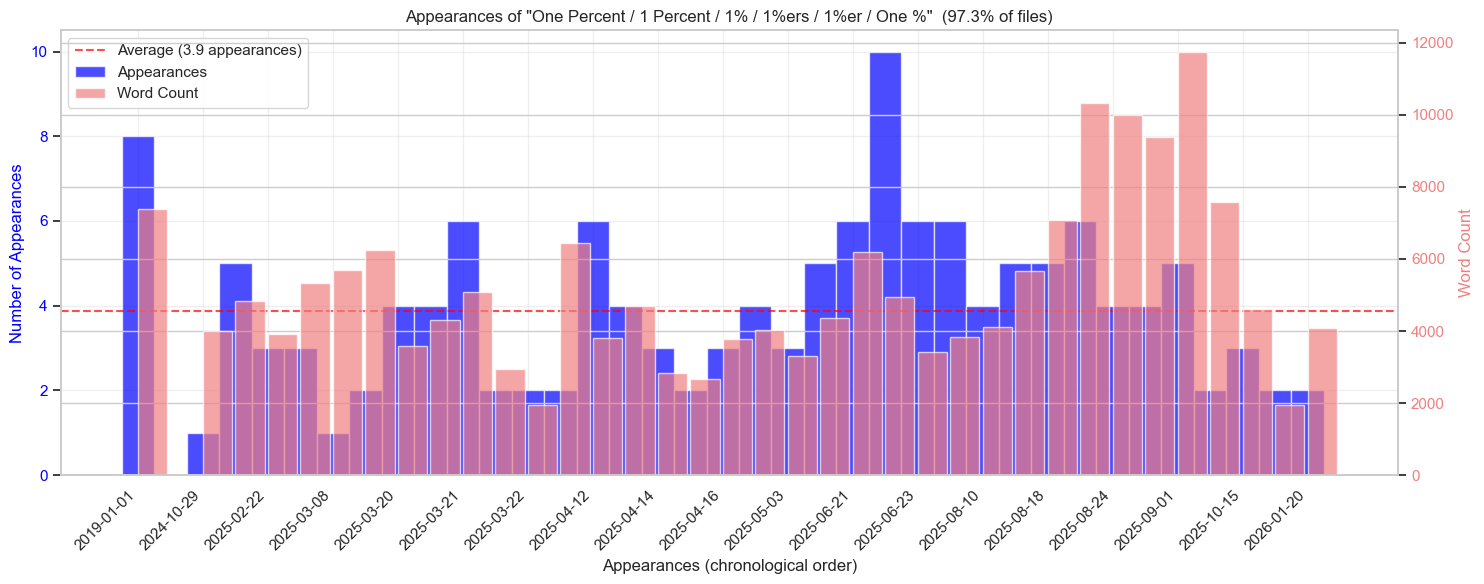


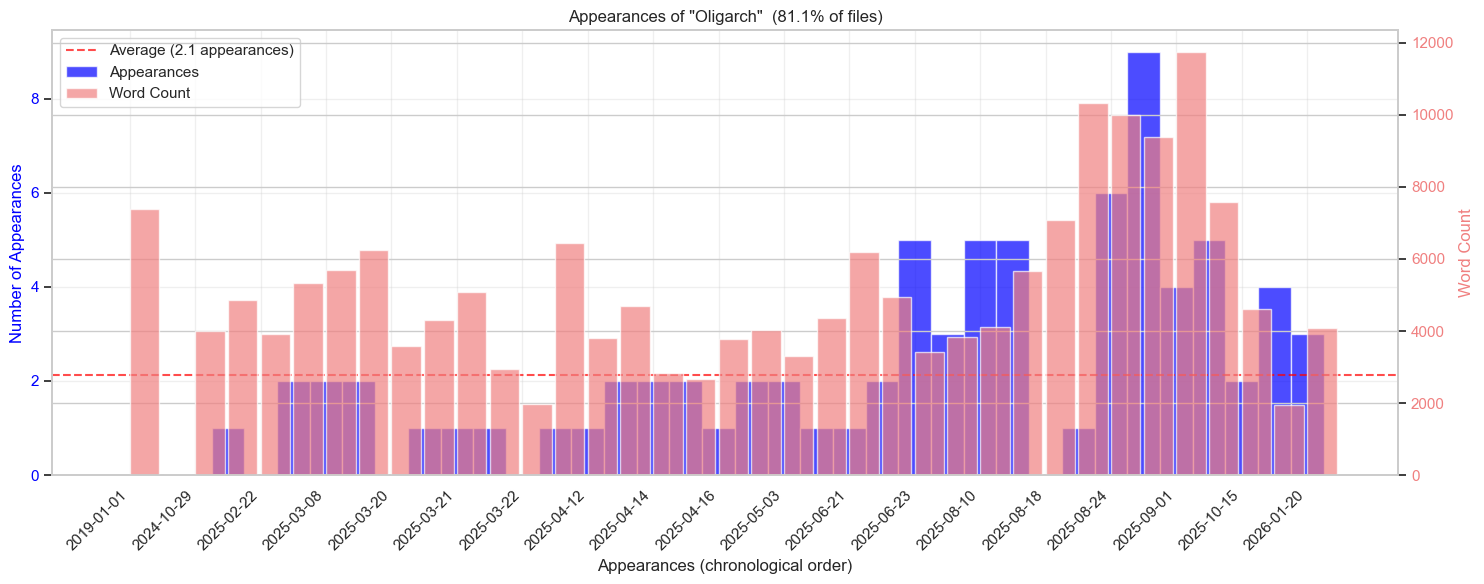

In [6]:
plot_phrases_individual_all(df, SEARCH_PHRASES, show_word_counts=True, spread_appearances_evenly=True)

In [10]:
df_town_hall = df[df['file'].str.contains('town hall|townhall|town|hall|brooklyn', case=False, na=False)]
df_new_jersey = df[df['file'].str.contains('no_kings|kings|rally', case=False, na=False)]
# analyze_files_phrase_occurrences(df_town_hall, SEARCH_PHRASES)
analyze_files_phrase_occurrences(df_new_jersey, SEARCH_PHRASES)

Found 1 matching files:

  Rally with Bernie & AOC in Madison, WI (LIVE at 830PM ET).20241029.txt


Phrase occurrences across selected files (sorted by total occurrences):


,"Rally with Bernie & AOC in Madison, WI (LIVE at 830PM ET).20241029.txt"
Word Count,3987
Trump,21
Billionaire,11
Middle Class / Working Class,7
Republican,6
Election,5
Afford / Affordable / Affordability,4
Paycheck to Paycheck,3
Climate,3
Elon / Musk,2



Summary:
Total files processed: 1
Total word count: 3,987


## Recent Usage in Context

In [8]:
get_recent_contexts_all(df, SEARCH_PHRASES, n=10)


=== Recent usage of 'Paycheck to Paycheck' ===

Title: 2026-1-20_fighting-oligarchy-new-jersey.txt
Date: 2026-01-20 (processed-transcripts)
Context: ...ck me because it is a very deep truth. We understand that we live in a nation today where never before have so few had so much. While so many people are struggling, while 60% of our people are living paycheck to paycheck. And I'm going to get into that stuff in a minute. But the more important point is not just that the big money and the billionaires own the economy. They do. It's not just that they buy and sell polit...

Title: 2026-1-20_fighting-oligarchy-new-jersey.txt
Date: 2026-01-20 (processed-transcripts)
Context: ...E agents terrorizing communities. >> [cheering and applause] [applause and cheering] [applause] [cheering] >> And we'll not accept an economy in which the rich get richer while 60% of our people live paycheck TO PAYCHECK. >> [applause] >> SO, >> LET ME JUST SAY A FEW WORDS that you don't hear much on TV and you're n